In [6]:
%pip install matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [7]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
sns.set_palette('husl')

# Tạo folder để lưu charts
output_folder = Path('cleaned_data_analysis')
output_folder.mkdir(exist_ok=True)

print("✓ Đã import thành công các thư viện!")
print(f"✓ Đã tạo folder: {output_folder.absolute()}")

✓ Đã import thành công các thư viện!
✓ Đã tạo folder: d:\codespace\python\BusHappy\backend\cleaned_data_analysis


## 1. Load Dữ Liệu

In [8]:
# Chọn ngày để phân tích
date = '2025-04-01'

# Đường dẫn file
raw_file = Path(f'Bus_route_data/raw_GPS/anonymized_raw_{date}.csv')
cleaned_file = Path(f'Bus_route_data/raw_GPS/cleaned/cleaned_anonymized_raw_{date}.csv')

print(f"Đang load dữ liệu ngày {date}...")
print("="*80)

# Load cleaned data
print("\n📥 Đang đọc cleaned data...")
df_cleaned = pd.read_csv(cleaned_file)
df_cleaned['datetime'] = pd.to_datetime(df_cleaned['datetime'])
print(f"✓ Cleaned data: {len(df_cleaned):,} records")
print(f"  Vehicles: {df_cleaned['anonymized_vehicle'].nunique()}")
print(f"  Memory: {df_cleaned.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Load raw data
print("\n📥 Đang đọc raw data...")
df_raw = pd.read_csv(raw_file)
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'])
df_raw = df_raw.dropna(subset=['speed'])
print(f"✓ Raw data: {len(df_raw):,} records")
print(f"  Vehicles: {df_raw['anonymized_vehicle'].nunique()}")
print(f"  Memory: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "="*80)
print("✓ Hoàn tất load dữ liệu!")

Đang load dữ liệu ngày 2025-04-01...

📥 Đang đọc cleaned data...
✓ Cleaned data: 2,343,951 records
  Vehicles: 459
  Memory: 207.89 MB

📥 Đang đọc raw data...
✓ Raw data: 1,269,296 records
  Vehicles: 459
  Memory: 203.99 MB

✓ Hoàn tất load dữ liệu!


## 2. Thống Kê Tổng Quan

In [9]:
# Bảng so sánh tổng quan
comparison_df = pd.DataFrame({
    'Metric': [
        'Tổng số records',
        'Số vehicles',
        'Records có speed > 0',
        'Tỷ lệ speed > 0 (%)',
        'Tốc độ trung bình (km/h)',
        'Tốc độ trung vị (km/h)',
        'Tốc độ min (km/h)',
        'Tốc độ max (km/h)',
        'Độ lệch chuẩn (km/h)',
        'Q1 - 25% (km/h)',
        'Q3 - 75% (km/h)'
    ],
    'Cleaned Data': [
        f"{len(df_cleaned):,}",
        f"{df_cleaned['anonymized_vehicle'].nunique()}",
        f"{(df_cleaned['speed'] > 0).sum():,}",
        f"{(df_cleaned['speed'] > 0).sum() / len(df_cleaned) * 100:.2f}",
        f"{df_cleaned[df_cleaned['speed'] > 0]['speed'].mean():.2f}",
        f"{df_cleaned[df_cleaned['speed'] > 0]['speed'].median():.2f}",
        f"{df_cleaned['speed'].min():.2f}",
        f"{df_cleaned['speed'].max():.2f}",
        f"{df_cleaned[df_cleaned['speed'] > 0]['speed'].std():.2f}",
        f"{df_cleaned['speed'].quantile(0.25):.2f}",
        f"{df_cleaned['speed'].quantile(0.75):.2f}"
    ],
    'Raw Data': [
        f"{len(df_raw):,}",
        f"{df_raw['anonymized_vehicle'].nunique()}",
        f"{(df_raw['speed'] > 0).sum():,}",
        f"{(df_raw['speed'] > 0).sum() / len(df_raw) * 100:.2f}",
        f"{df_raw[df_raw['speed'] > 0]['speed'].mean():.2f}",
        f"{df_raw[df_raw['speed'] > 0]['speed'].median():.2f}",
        f"{df_raw['speed'].min():.2f}",
        f"{df_raw['speed'].max():.2f}",
        f"{df_raw[df_raw['speed'] > 0]['speed'].std():.2f}",
        f"{df_raw['speed'].quantile(0.25):.2f}",
        f"{df_raw['speed'].quantile(0.75):.2f}"
    ]
})

print("="*80)
print("BẢNG SO SÁNH TỔNG QUAN")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

BẢNG SO SÁNH TỔNG QUAN
                  Metric Cleaned Data  Raw Data
         Tổng số records    2,343,951 1,269,296
             Số vehicles          459       459
    Records có speed > 0    1,329,896 1,269,296
     Tỷ lệ speed > 0 (%)        56.74    100.00
Tốc độ trung bình (km/h)        21.79     22.40
  Tốc độ trung vị (km/h)        21.19     22.00
       Tốc độ min (km/h)         0.00      1.00
       Tốc độ max (km/h)       100.00     94.00
    Độ lệch chuẩn (km/h)        13.35     12.59
         Q1 - 25% (km/h)         0.00     12.00
         Q3 - 75% (km/h)        23.32     31.00


## 3. Visualize Phân Phối Tốc Độ

✓ Đã lưu: cleaned_data_analysis\01_speed_distribution_2025-04-01.png


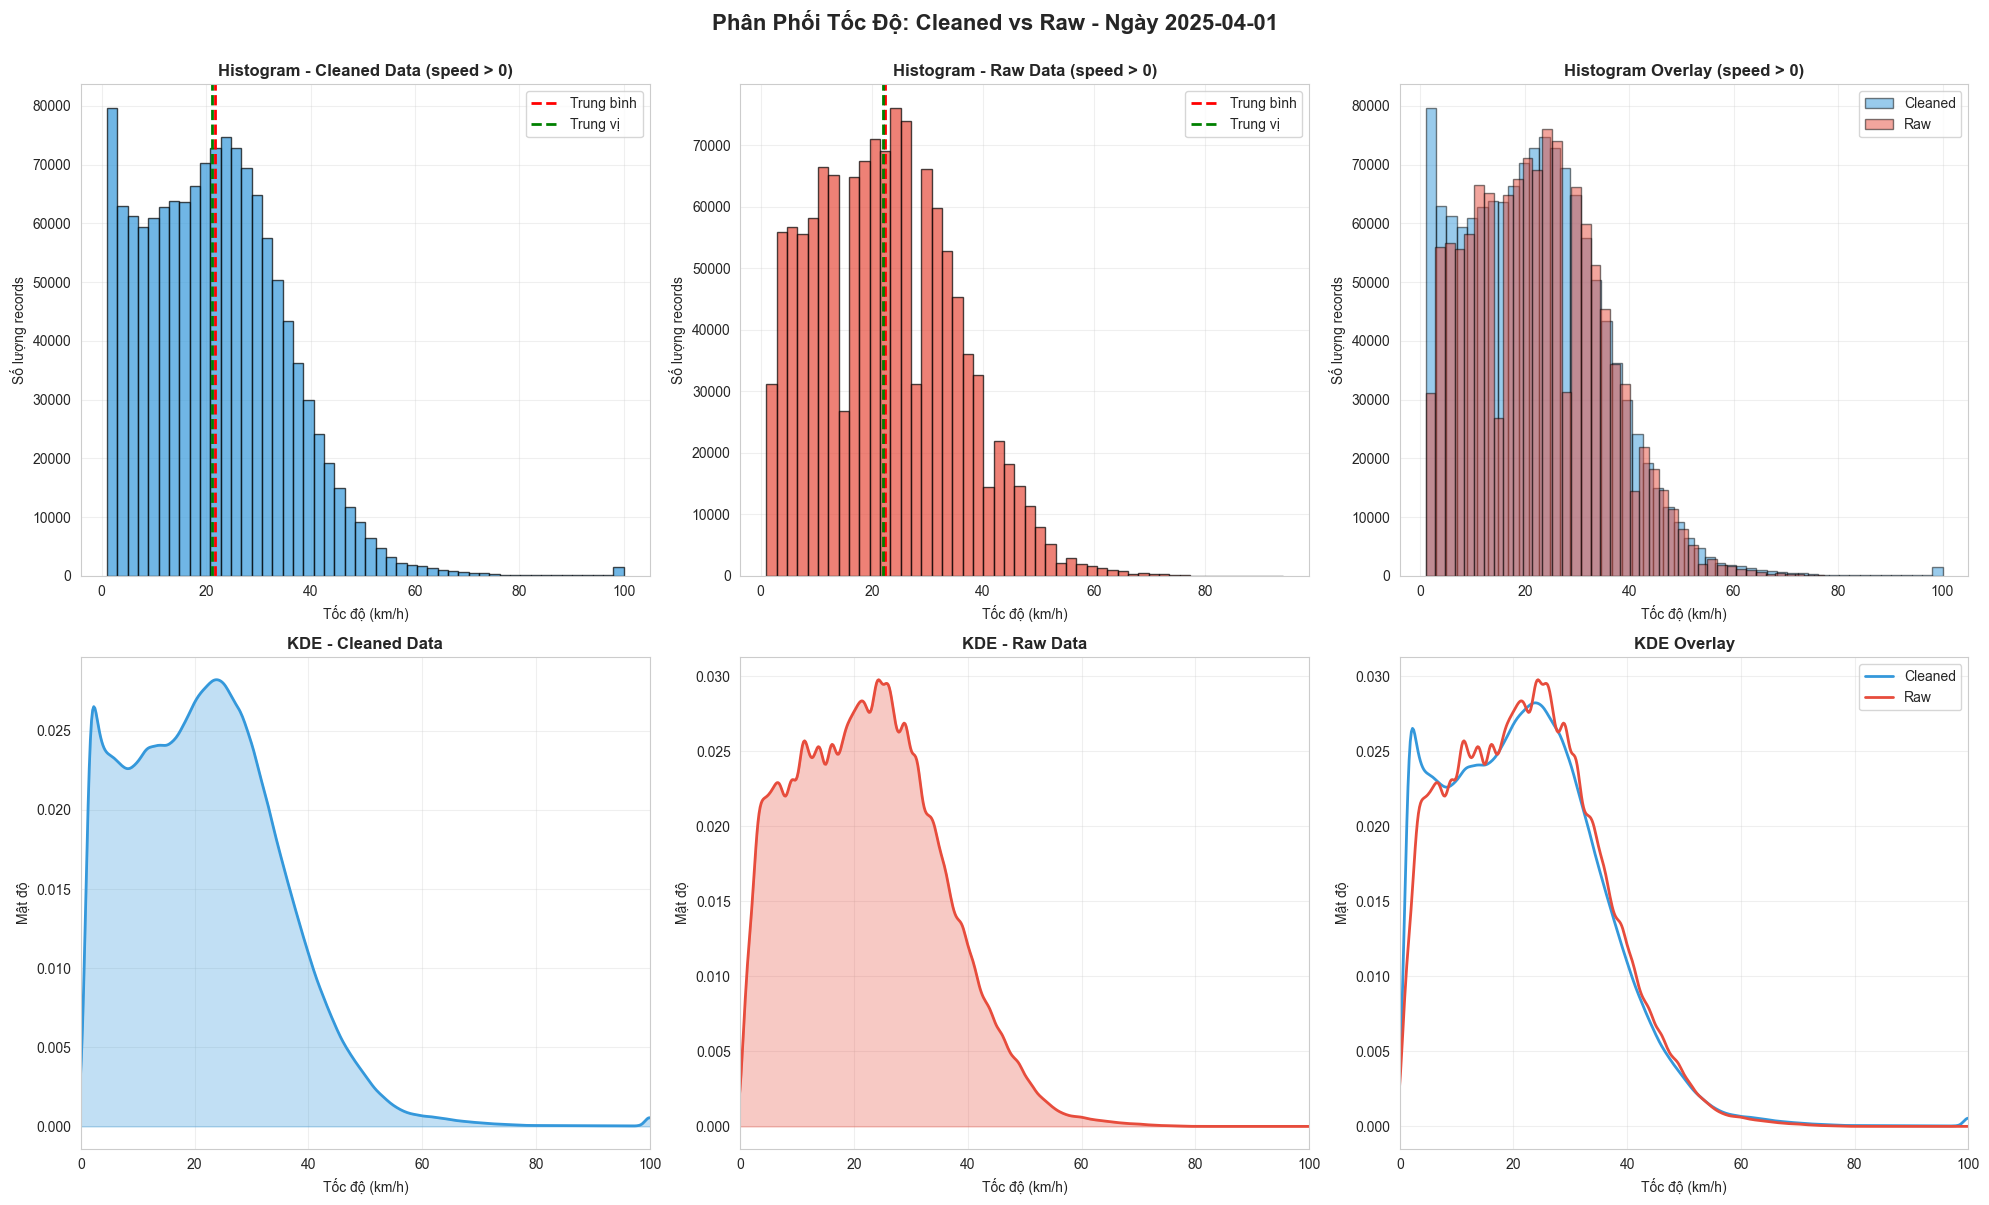

In [10]:
# Tạo figure với 6 subplots
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f'Phân Phối Tốc Độ: Cleaned vs Raw - Ngày {date}', fontsize=16, fontweight='bold', y=1.00)

# 1. Histogram Cleaned
ax1 = axes[0, 0]
df_cleaned[df_cleaned['speed'] > 0]['speed'].hist(bins=50, ax=ax1, color='#3498db', edgecolor='black', alpha=0.7)
ax1.axvline(df_cleaned[df_cleaned['speed'] > 0]['speed'].mean(), color='red', linestyle='--', linewidth=2, label='Trung bình')
ax1.axvline(df_cleaned[df_cleaned['speed'] > 0]['speed'].median(), color='green', linestyle='--', linewidth=2, label='Trung vị')
ax1.set_title('Histogram - Cleaned Data (speed > 0)', fontweight='bold')
ax1.set_xlabel('Tốc độ (km/h)')
ax1.set_ylabel('Số lượng records')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Histogram Raw
ax2 = axes[0, 1]
df_raw[df_raw['speed'] > 0]['speed'].hist(bins=50, ax=ax2, color='#e74c3c', edgecolor='black', alpha=0.7)
ax2.axvline(df_raw[df_raw['speed'] > 0]['speed'].mean(), color='red', linestyle='--', linewidth=2, label='Trung bình')
ax2.axvline(df_raw[df_raw['speed'] > 0]['speed'].median(), color='green', linestyle='--', linewidth=2, label='Trung vị')
ax2.set_title('Histogram - Raw Data (speed > 0)', fontweight='bold')
ax2.set_xlabel('Tốc độ (km/h)')
ax2.set_ylabel('Số lượng records')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Histogram Overlay
ax3 = axes[0, 2]
ax3.hist(df_cleaned[df_cleaned['speed'] > 0]['speed'], bins=50, alpha=0.5, label='Cleaned', color='#3498db', edgecolor='black')
ax3.hist(df_raw[df_raw['speed'] > 0]['speed'], bins=50, alpha=0.5, label='Raw', color='#e74c3c', edgecolor='black')
ax3.set_title('Histogram Overlay (speed > 0)', fontweight='bold')
ax3.set_xlabel('Tốc độ (km/h)')
ax3.set_ylabel('Số lượng records')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. KDE Cleaned
ax4 = axes[1, 0]
df_cleaned[df_cleaned['speed'] > 0]['speed'].plot(kind='kde', ax=ax4, color='#3498db', linewidth=2)
ax4.fill_between(ax4.lines[0].get_xdata(), ax4.lines[0].get_ydata(), alpha=0.3, color='#3498db')
ax4.set_title('KDE - Cleaned Data', fontweight='bold')
ax4.set_xlabel('Tốc độ (km/h)')
ax4.set_ylabel('Mật độ')
ax4.set_xlim(0, 100)
ax4.grid(True, alpha=0.3)

# 5. KDE Raw
ax5 = axes[1, 1]
df_raw[df_raw['speed'] > 0]['speed'].plot(kind='kde', ax=ax5, color='#e74c3c', linewidth=2)
ax5.fill_between(ax5.lines[0].get_xdata(), ax5.lines[0].get_ydata(), alpha=0.3, color='#e74c3c')
ax5.set_title('KDE - Raw Data', fontweight='bold')
ax5.set_xlabel('Tốc độ (km/h)')
ax5.set_ylabel('Mật độ')
ax5.set_xlim(0, 100)
ax5.grid(True, alpha=0.3)

# 6. KDE Overlay
ax6 = axes[1, 2]
df_cleaned[df_cleaned['speed'] > 0]['speed'].plot(kind='kde', ax=ax6, label='Cleaned', color='#3498db', linewidth=2)
df_raw[df_raw['speed'] > 0]['speed'].plot(kind='kde', ax=ax6, label='Raw', color='#e74c3c', linewidth=2)
ax6.set_title('KDE Overlay', fontweight='bold')
ax6.set_xlabel('Tốc độ (km/h)')
ax6.set_ylabel('Mật độ')
ax6.set_xlim(0, 100)
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
# Lưu chart
chart_path = output_folder / f'01_speed_distribution_{date}.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
print(f"✓ Đã lưu: {chart_path}")
plt.show()

## 4. Box Plot & Violin Plot So Sánh

✓ Đã lưu: cleaned_data_analysis\02_boxplot_violin_2025-04-01.png


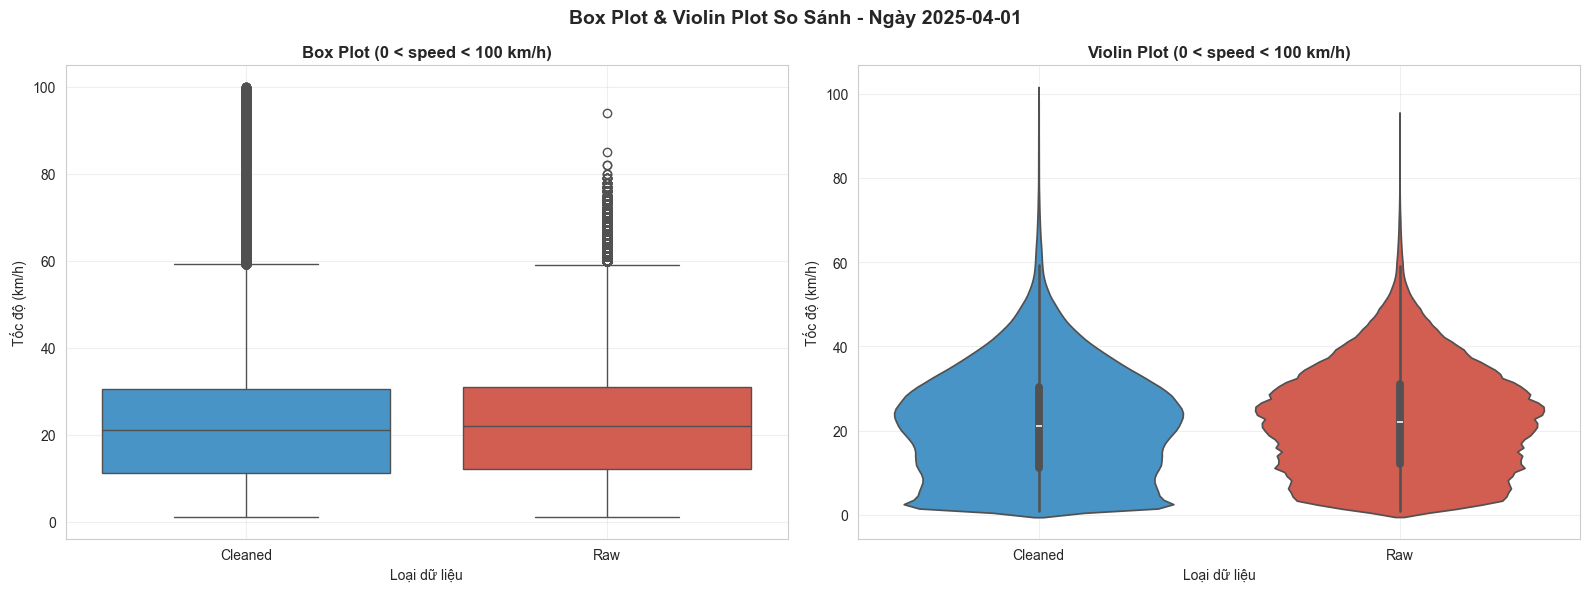

In [11]:
# Chuẩn bị dữ liệu để so sánh (giới hạn < 100 km/h để dễ visualize)
data_compare = pd.concat([
    df_cleaned[(df_cleaned['speed'] > 0) & (df_cleaned['speed'] < 100)][['speed']].assign(Type='Cleaned'),
    df_raw[(df_raw['speed'] > 0) & (df_raw['speed'] < 100)][['speed']].assign(Type='Raw')
])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Box Plot & Violin Plot So Sánh - Ngày {date}', fontsize=14, fontweight='bold')

# Box plot
sns.boxplot(data=data_compare, x='Type', y='speed', ax=axes[0], palette=['#3498db', '#e74c3c'])
axes[0].set_title('Box Plot (0 < speed < 100 km/h)', fontweight='bold')
axes[0].set_xlabel('Loại dữ liệu')
axes[0].set_ylabel('Tốc độ (km/h)')
axes[0].grid(True, alpha=0.3)

# Violin plot
sns.violinplot(data=data_compare, x='Type', y='speed', ax=axes[1], palette=['#3498db', '#e74c3c'])
axes[1].set_title('Violin Plot (0 < speed < 100 km/h)', fontweight='bold')
axes[1].set_xlabel('Loại dữ liệu')
axes[1].set_ylabel('Tốc độ (km/h)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# Lưu chart
chart_path = output_folder / f'02_boxplot_violin_{date}.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
print(f"✓ Đã lưu: {chart_path}")
plt.show()

## 5. So Sánh Các Metric Thống Kê

✓ Đã lưu: cleaned_data_analysis\03_metrics_comparison_2025-04-01.png


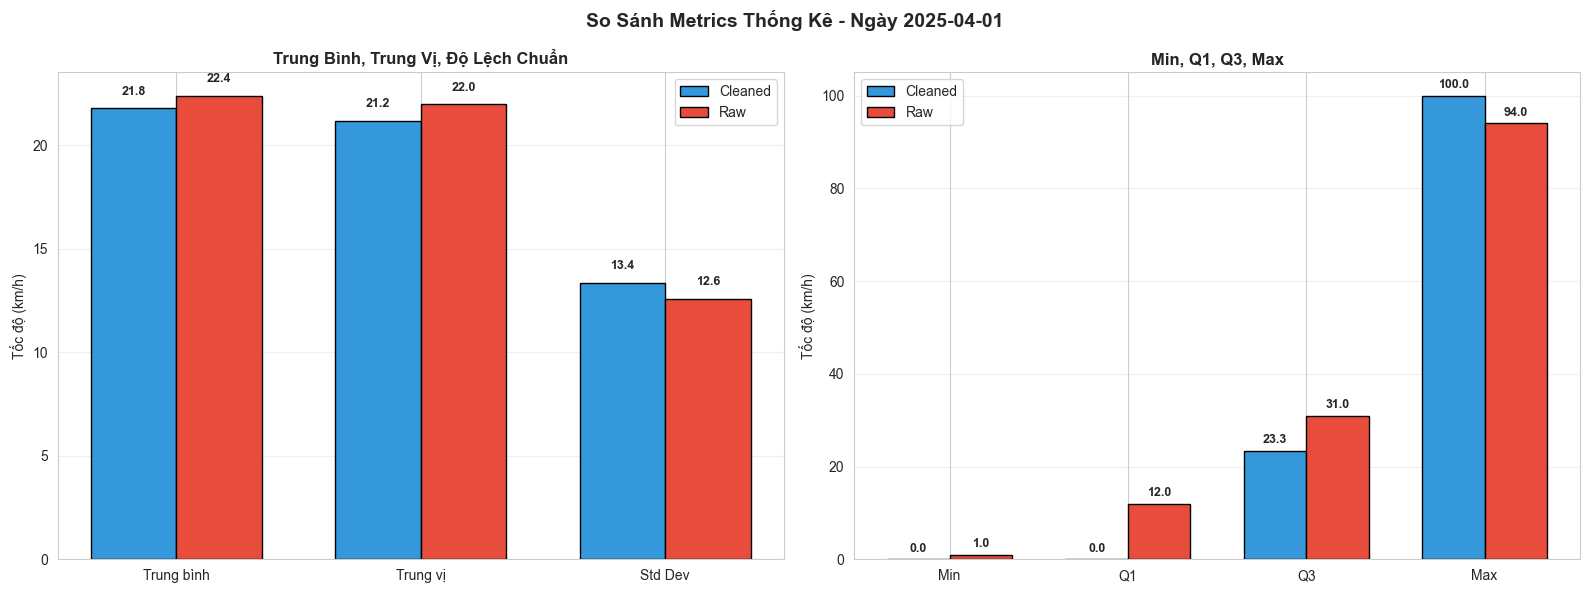

In [12]:
# Bar chart so sánh các metric chính
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'So Sánh Metrics Thống Kê - Ngày {date}', fontsize=14, fontweight='bold')

# 1. Trung bình, Trung vị, Std Dev
metrics1 = ['Trung bình', 'Trung vị', 'Std Dev']
cleaned_values1 = [
    df_cleaned[df_cleaned['speed'] > 0]['speed'].mean(),
    df_cleaned[df_cleaned['speed'] > 0]['speed'].median(),
    df_cleaned[df_cleaned['speed'] > 0]['speed'].std()
]
raw_values1 = [
    df_raw[df_raw['speed'] > 0]['speed'].mean(),
    df_raw[df_raw['speed'] > 0]['speed'].median(),
    df_raw[df_raw['speed'] > 0]['speed'].std()
]

x1 = np.arange(len(metrics1))
width = 0.35
axes[0].bar(x1 - width/2, cleaned_values1, width, label='Cleaned', color='#3498db', edgecolor='black')
axes[0].bar(x1 + width/2, raw_values1, width, label='Raw', color='#e74c3c', edgecolor='black')
axes[0].set_title('Trung Bình, Trung Vị, Độ Lệch Chuẩn', fontweight='bold')
axes[0].set_ylabel('Tốc độ (km/h)')
axes[0].set_xticks(x1)
axes[0].set_xticklabels(metrics1)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Thêm giá trị lên bar
for i, (c, r) in enumerate(zip(cleaned_values1, raw_values1)):
    axes[0].text(i - width/2, c + 0.5, f'{c:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    axes[0].text(i + width/2, r + 0.5, f'{r:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# 2. Min, Max, Q1, Q3
metrics2 = ['Min', 'Q1', 'Q3', 'Max']
cleaned_values2 = [
    df_cleaned['speed'].min(),
    df_cleaned['speed'].quantile(0.25),
    df_cleaned['speed'].quantile(0.75),
    df_cleaned['speed'].max()
]
raw_values2 = [
    df_raw['speed'].min(),
    df_raw['speed'].quantile(0.25),
    df_raw['speed'].quantile(0.75),
    df_raw['speed'].max()
]

x2 = np.arange(len(metrics2))
axes[1].bar(x2 - width/2, cleaned_values2, width, label='Cleaned', color='#3498db', edgecolor='black')
axes[1].bar(x2 + width/2, raw_values2, width, label='Raw', color='#e74c3c', edgecolor='black')
axes[1].set_title('Min, Q1, Q3, Max', fontweight='bold')
axes[1].set_ylabel('Tốc độ (km/h)')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(metrics2)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Thêm giá trị lên bar
for i, (c, r) in enumerate(zip(cleaned_values2, raw_values2)):
    axes[1].text(i - width/2, c + 1, f'{c:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    axes[1].text(i + width/2, r + 1, f'{r:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
# Lưu chart
chart_path = output_folder / f'03_metrics_comparison_{date}.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
print(f"✓ Đã lưu: {chart_path}")
plt.show()

## 6. Phân Tích Theo Thời Gian

✓ Đã lưu: cleaned_data_analysis\04_hourly_analysis_2025-04-01.png


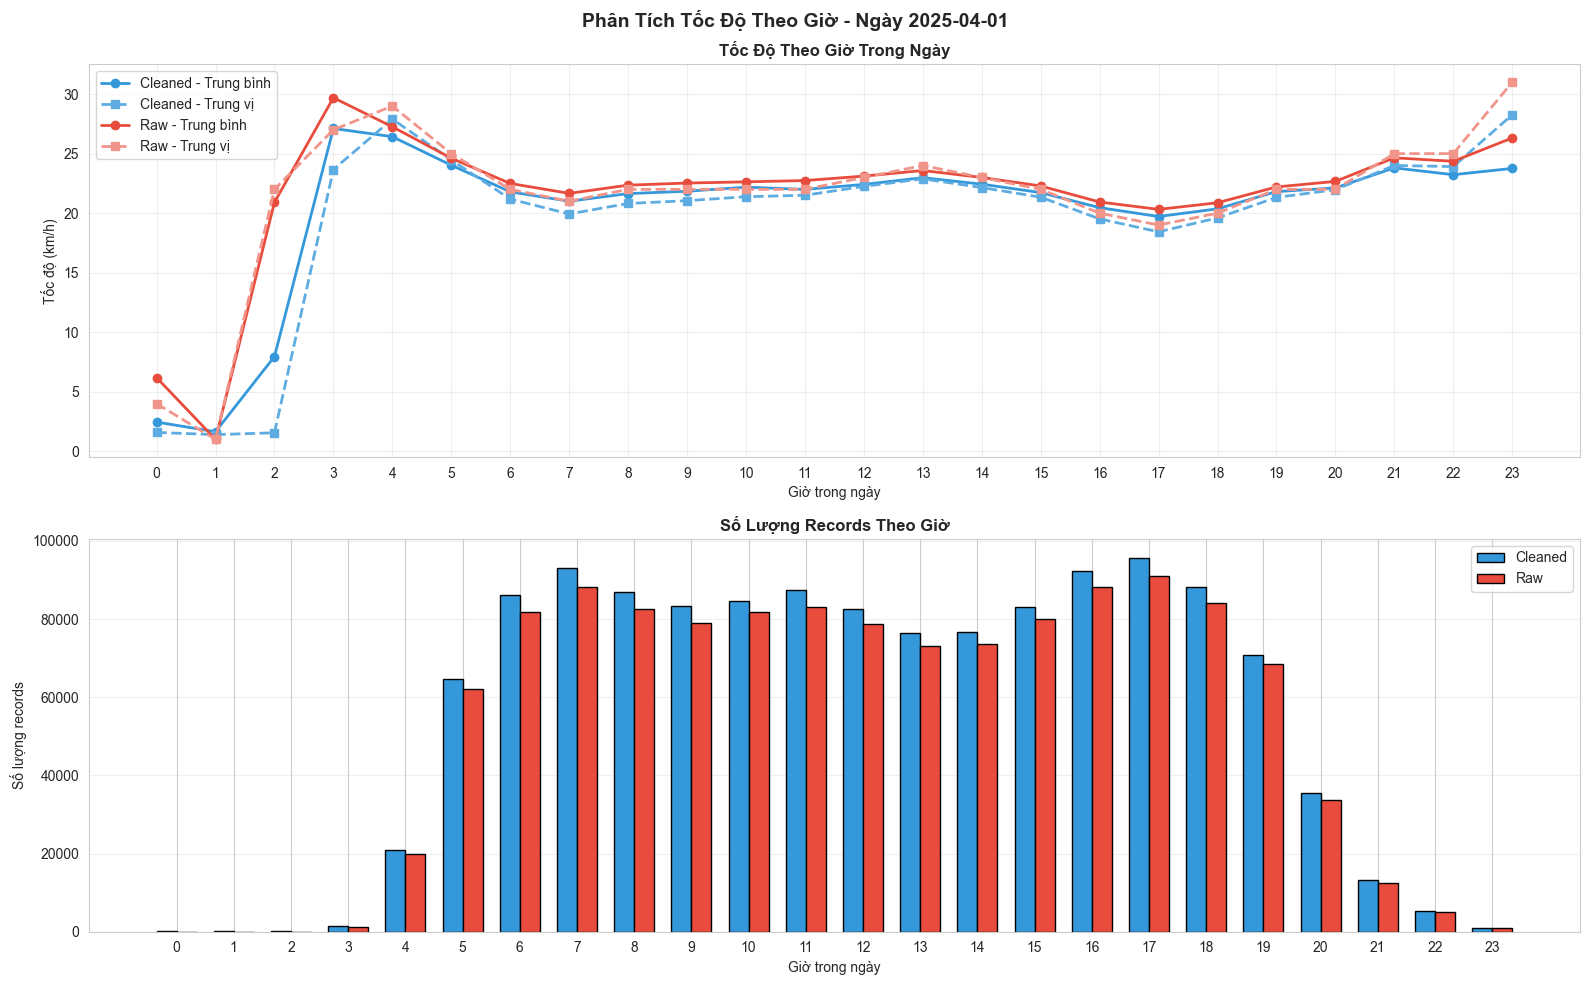

In [13]:
# Tốc độ theo giờ trong ngày
df_cleaned['hour'] = df_cleaned['datetime'].dt.hour
df_raw['hour'] = df_raw['datetime'].dt.hour

hourly_cleaned = df_cleaned[df_cleaned['speed'] > 0].groupby('hour')['speed'].agg(['mean', 'median', 'count']).reset_index()
hourly_raw = df_raw[df_raw['speed'] > 0].groupby('hour')['speed'].agg(['mean', 'median', 'count']).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle(f'Phân Tích Tốc Độ Theo Giờ - Ngày {date}', fontsize=14, fontweight='bold')

# 1. Tốc độ trung bình và trung vị theo giờ
ax1 = axes[0]
ax1.plot(hourly_cleaned['hour'], hourly_cleaned['mean'], marker='o', linewidth=2, label='Cleaned - Trung bình', color='#3498db')
ax1.plot(hourly_cleaned['hour'], hourly_cleaned['median'], marker='s', linewidth=2, label='Cleaned - Trung vị', color='#5dade2', linestyle='--')
ax1.plot(hourly_raw['hour'], hourly_raw['mean'], marker='o', linewidth=2, label='Raw - Trung bình', color='#e74c3c')
ax1.plot(hourly_raw['hour'], hourly_raw['median'], marker='s', linewidth=2, label='Raw - Trung vị', color='#f1948a', linestyle='--')
ax1.set_title('Tốc Độ Theo Giờ Trong Ngày', fontweight='bold')
ax1.set_xlabel('Giờ trong ngày')
ax1.set_ylabel('Tốc độ (km/h)')
ax1.set_xticks(range(0, 24))
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# 2. Số lượng records theo giờ
ax2 = axes[1]
x = np.arange(24)
width = 0.35
ax2.bar(x - width/2, hourly_cleaned['count'], width, label='Cleaned', color='#3498db', edgecolor='black')
ax2.bar(x + width/2, hourly_raw['count'], width, label='Raw', color='#e74c3c', edgecolor='black')
ax2.set_title('Số Lượng Records Theo Giờ', fontweight='bold')
ax2.set_xlabel('Giờ trong ngày')
ax2.set_ylabel('Số lượng records')
ax2.set_xticks(range(0, 24))
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
# Lưu chart
chart_path = output_folder / f'04_hourly_analysis_{date}.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
print(f"✓ Đã lưu: {chart_path}")
plt.show()

## 7. Phân Phối Tốc Độ Theo Khoảng

✓ Đã lưu: cleaned_data_analysis\05_speed_categories_2025-04-01.png


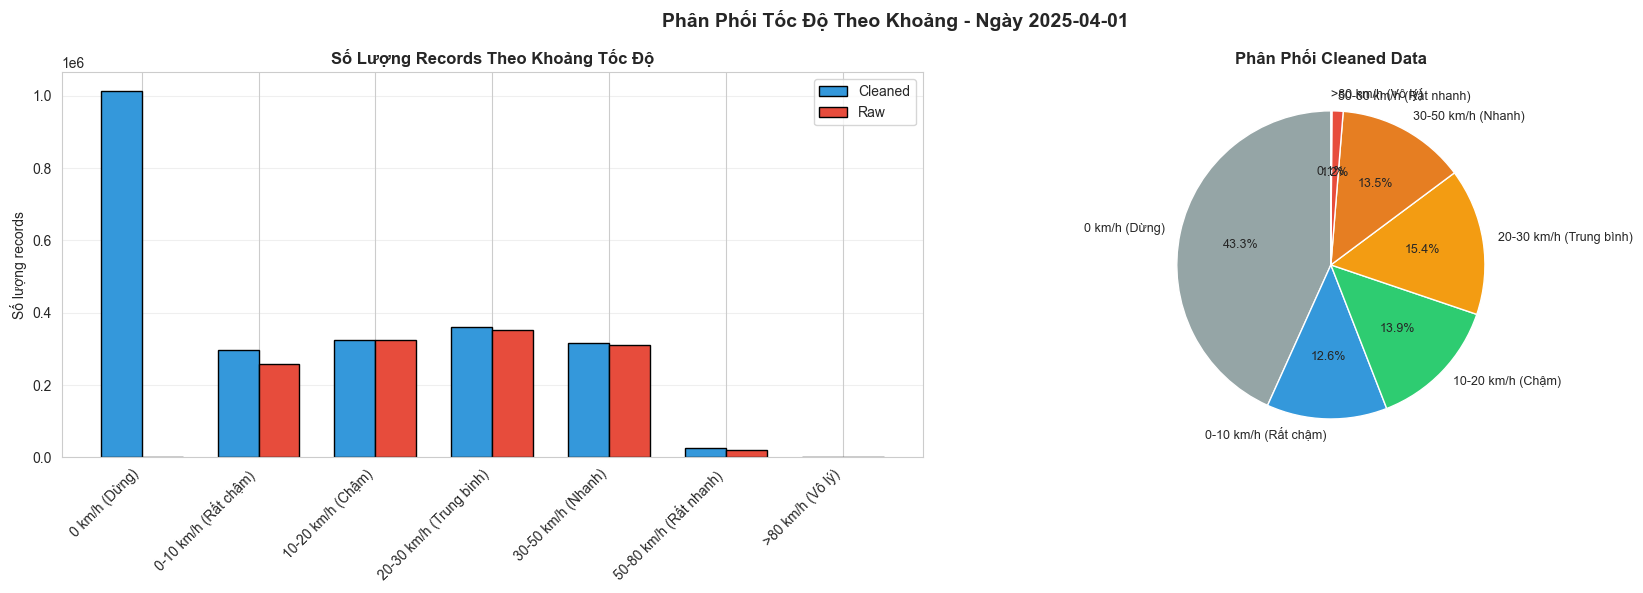


PHÂN PHỐI TỐC ĐỘ THEO KHOẢNG
          Khoảng tốc độ  Cleaned - Số lượng Cleaned - %  Raw - Số lượng Raw - %
          0 km/h (Dừng)             1014055      43.26%               0   0.00%
   0-10 km/h (Rất chậm)              296247      12.64%          257541  20.29%
      10-20 km/h (Chậm)              325745      13.90%          325811  25.67%
20-30 km/h (Trung bình)              360830      15.39%          352555  27.78%
     30-50 km/h (Nhanh)              317109      13.53%          311446  24.54%
 50-80 km/h (Rất nhanh)               27523       1.17%           21939   1.73%
       >80 km/h (Vô lý)                2442       0.10%               4   0.00%


In [14]:
# Phân loại tốc độ theo khoảng
def categorize_speed(speed):
    if speed == 0:
        return '0 km/h (Dừng)'
    elif speed <= 10:
        return '0-10 km/h (Rất chậm)'
    elif speed <= 20:
        return '10-20 km/h (Chậm)'
    elif speed <= 30:
        return '20-30 km/h (Trung bình)'
    elif speed <= 50:
        return '30-50 km/h (Nhanh)'
    elif speed <= 80:
        return '50-80 km/h (Rất nhanh)'
    else:
        return '>80 km/h (Vô lý)'

df_cleaned['speed_category'] = df_cleaned['speed'].apply(categorize_speed)
df_raw['speed_category'] = df_raw['speed'].apply(categorize_speed)

# Đếm số lượng
cleaned_counts = df_cleaned['speed_category'].value_counts().reindex([
    '0 km/h (Dừng)', '0-10 km/h (Rất chậm)', '10-20 km/h (Chậm)', 
    '20-30 km/h (Trung bình)', '30-50 km/h (Nhanh)', '50-80 km/h (Rất nhanh)', '>80 km/h (Vô lý)'
], fill_value=0)

raw_counts = df_raw['speed_category'].value_counts().reindex([
    '0 km/h (Dừng)', '0-10 km/h (Rất chậm)', '10-20 km/h (Chậm)', 
    '20-30 km/h (Trung bình)', '30-50 km/h (Nhanh)', '50-80 km/h (Rất nhanh)', '>80 km/h (Vô lý)'
], fill_value=0)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'Phân Phối Tốc Độ Theo Khoảng - Ngày {date}', fontsize=14, fontweight='bold')

# 1. Bar chart so sánh
x = np.arange(len(cleaned_counts))
width = 0.35
axes[0].bar(x - width/2, cleaned_counts.values, width, label='Cleaned', color='#3498db', edgecolor='black')
axes[0].bar(x + width/2, raw_counts.values, width, label='Raw', color='#e74c3c', edgecolor='black')
axes[0].set_title('Số Lượng Records Theo Khoảng Tốc Độ', fontweight='bold')
axes[0].set_ylabel('Số lượng records')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cleaned_counts.index, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Pie chart - Cleaned
colors = ['#95a5a6', '#3498db', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad']
axes[1].pie(cleaned_counts.values, labels=cleaned_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 9})
axes[1].set_title('Phân Phối Cleaned Data', fontweight='bold')

plt.tight_layout()
# Lưu chart
chart_path = output_folder / f'05_speed_categories_{date}.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
print(f"✓ Đã lưu: {chart_path}")
plt.show()

# In bảng thống kê
print("\n" + "="*80)
print("PHÂN PHỐI TỐC ĐỘ THEO KHOẢNG")
print("="*80)
category_df = pd.DataFrame({
    'Khoảng tốc độ': cleaned_counts.index,
    'Cleaned - Số lượng': cleaned_counts.values,
    'Cleaned - %': [f"{v/len(df_cleaned)*100:.2f}%" for v in cleaned_counts.values],
    'Raw - Số lượng': raw_counts.values,
    'Raw - %': [f"{v/len(df_raw)*100:.2f}%" for v in raw_counts.values]
})
print(category_df.to_string(index=False))
print("="*80)

## 8. Top Vehicles Phân Tích

✓ Đã lưu: cleaned_data_analysis\06_top_vehicles_2025-04-01.png


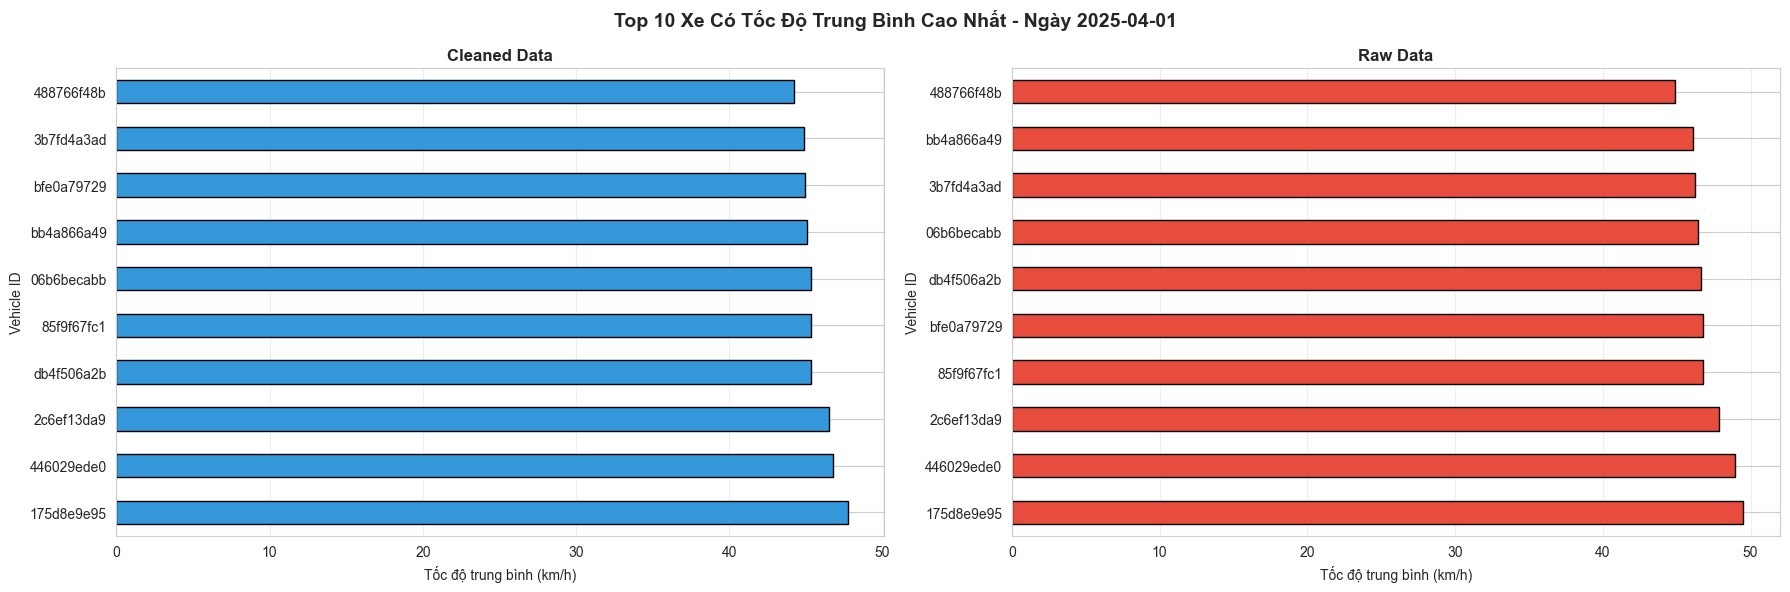

In [15]:
# Top 10 xe có tốc độ trung bình cao nhất
top_vehicles_cleaned = df_cleaned[df_cleaned['speed'] > 0].groupby('anonymized_vehicle')['speed'].mean().nlargest(10)
top_vehicles_raw = df_raw[df_raw['speed'] > 0].groupby('anonymized_vehicle')['speed'].mean().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'Top 10 Xe Có Tốc Độ Trung Bình Cao Nhất - Ngày {date}', fontsize=14, fontweight='bold')

# Cleaned
top_vehicles_cleaned.plot(kind='barh', ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('Cleaned Data', fontweight='bold')
axes[0].set_xlabel('Tốc độ trung bình (km/h)')
axes[0].set_ylabel('Vehicle ID')
axes[0].grid(True, alpha=0.3, axis='x')

# Raw
top_vehicles_raw.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Raw Data', fontweight='bold')
axes[1].set_xlabel('Tốc độ trung bình (km/h)')
axes[1].set_ylabel('Vehicle ID')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
# Lưu chart
chart_path = output_folder / f'06_top_vehicles_{date}.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
print(f"✓ Đã lưu: {chart_path}")
plt.show()

## 9. Tổng Kết

Notebook này đã visualize và so sánh:

### ✓ Các phân tích đã thực hiện:
1. **Thống kê tổng quan** - Bảng so sánh các metrics chính
2. **Phân phối tốc độ** - Histogram, KDE của cleaned và raw data
3. **Box plot & Violin plot** - So sánh phân phối
4. **So sánh metrics** - Trung bình, trung vị, độ lệch chuẩn, quartiles
5. **Phân tích theo thời gian** - Tốc độ và số lượng records theo giờ
6. **Phân phối theo khoảng** - Categorization tốc độ
7. **Top vehicles** - Xe có tốc độ trung bình cao nhất

### 📊 Charts đã được lưu vào folder `cleaned_data_analysis/`:
1. `01_speed_distribution_{date}.png` - Phân phối tốc độ
2. `02_boxplot_violin_{date}.png` - Box plot & Violin plot
3. `03_metrics_comparison_{date}.png` - So sánh metrics
4. `04_hourly_analysis_{date}.png` - Phân tích theo giờ
5. `05_speed_categories_{date}.png` - Phân phối theo khoảng
6. `06_top_vehicles_{date}.png` - Top vehicles

### 🎯 Kết luận chính:
- **Cleaned data** đã được cải thiện với:
  - Loại bỏ duplicates
  - Tính toán tốc độ chính xác hơn
  - Giới hạn tốc độ max ở 100 km/h (lọc GPS noise)
  - Tốc độ < 1 km/h được set về 0

### 📝 Để phân tích ngày khác:
Thay đổi biến `date` ở cell thứ 2 và chạy lại toàn bộ notebook.